# tslearn: работа 16 (датасет из работы 9)

В этой работе используется тот же датасет, что и в 9-й лабораторной: **ItalyPowerDemand**.

Ниже: загрузка данных, визуализация, классификация и кластеризация с помощью `tslearn`.


In [20]:
# Импорты
!pip install tslearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.svm import TimeSeriesSVC
from tslearn.clustering import TimeSeriesKMeans, silhouette_score

from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score


In [21]:
# Упражнение 1: загружаем датасет из лабы 9
dataset_name = 'ItalyPowerDemand'
ucr = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ucr.load_dataset(dataset_name)

print(f'Датасет: {dataset_name}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Классы train: {np.unique(y_train)}')

Датасет: ItalyPowerDemand
X_train: (67, 24, 1), X_test: (1029, 24, 1)
Классы train: [1 2]


In [22]:
# Упражнение 2: смотрим базовую статистику данных
summary = pd.DataFrame({
    'n_train': [X_train.shape[0]],
    'n_test': [X_test.shape[0]],
    'series_len': [X_train.shape[1]],
    'n_dims': [X_train.shape[2]],
    'n_classes': [len(np.unique(y_train))]
})

display(summary)

,n_train,n_test,series_len,n_dims,n_classes
0,67,1029,24,1,2


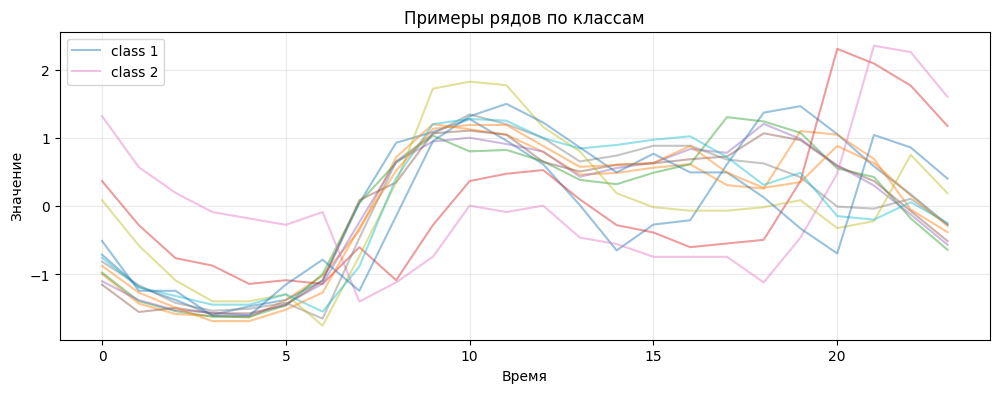

In [23]:
# Упражнение 3: отрисовываем ряды по классам
plt.figure(figsize=(12, 4))
classes = np.unique(y_train)
for cls in classes:
    idx = np.where(y_train == cls)[0][:6]
    for i in idx:
        plt.plot(X_train[i, :, 0], alpha=0.45, label=f'class {cls}' if i == idx[0] else None)

plt.title('Примеры рядов по классам')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [24]:
# Упражнение 4: масштабируем ряды (среднее=0, std=1)
scaler = TimeSeriesScalerMeanVariance()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('После масштабирования:')
print('X_train_scaled:', X_train_scaled.shape)
print('X_test_scaled:', X_test_scaled.shape)

После масштабирования:
X_train_scaled: (67, 24, 1)
X_test_scaled: (1029, 24, 1)


## Классификация (tslearn)

Сравниваем три модели: `KNN (euclidean)`, `KNN (dtw)` и `TimeSeriesSVC (GAK)`.


In [25]:
# Упражнение 5: классификация - три модели
cls_models = {
    'KNN_euclidean': KNeighborsTimeSeriesClassifier(n_neighbors=1, metric='euclidean'),
    'KNN_dtw': KNeighborsTimeSeriesClassifier(n_neighbors=1, metric='dtw'),
    'TS_SVC_gak': TimeSeriesSVC(kernel='gak', gamma='auto')
}

cls_results = []
predictions = {}

for name, model in cls_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    cls_results.append({'model': name, 'accuracy': acc})

cls_results_df = pd.DataFrame(cls_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
display(cls_results_df)

,model,accuracy
0,KNN_euclidean,0.955296
1,KNN_dtw,0.950437
2,TS_SVC_gak,0.949466


In [26]:
# Упражнение 6: отчёт по лучшей модели классификации
best_cls_name = cls_results_df.iloc[0]['model']
best_cls_pred = predictions[best_cls_name]

print(f'Лучшая модель: {best_cls_name}')
print(classification_report(y_test, best_cls_pred))

Лучшая модель: KNN_euclidean
              precision    recall  f1-score   support

           1       0.96      0.95      0.95       513
           2       0.95      0.96      0.96       516

    accuracy                           0.96      1029
   macro avg       0.96      0.96      0.96      1029
weighted avg       0.96      0.96      0.96      1029



## Кластеризация (tslearn)

Пробуем `TimeSeriesKMeans` с тремя метриками: `euclidean`, `dtw`, `softdtw`.


In [27]:
# Упражнение 7: кластеризация - три варианта TimeSeriesKMeans
n_clusters = len(np.unique(y_train))
cluster_models = {
    'KMeans_euclidean': TimeSeriesKMeans(n_clusters=n_clusters, metric='euclidean', random_state=42),
    'KMeans_dtw': TimeSeriesKMeans(n_clusters=n_clusters, metric='dtw', random_state=42),
    'KMeans_softdtw': TimeSeriesKMeans(n_clusters=n_clusters, metric='softdtw', random_state=42)
}

cluster_results = []
cluster_labels = {}

for name, model in cluster_models.items():
    labels = model.fit_predict(X_train_scaled)
    cluster_labels[name] = labels
    ari = adjusted_rand_score(y_train, labels)
    sil = silhouette_score(X_train_scaled, labels, metric='euclidean')
    cluster_results.append({
        'model': name,
        'ARI': ari,
        'silhouette_euclidean': sil
    })

cluster_results_df = pd.DataFrame(cluster_results).sort_values('ARI', ascending=False).reset_index(drop=True)
display(cluster_results_df)

,model,ARI,silhouette_euclidean
0,KMeans_dtw,0.012951,0.389960
1,KMeans_euclidean,0.002522,0.540941
2,KMeans_softdtw,-0.009172,0.480310


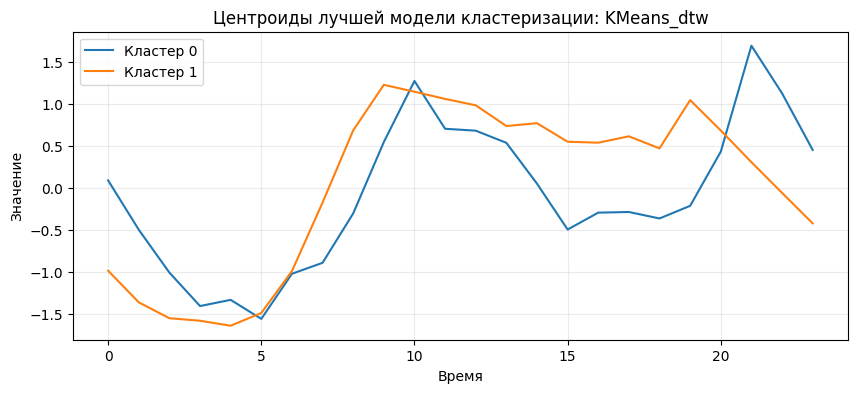

In [28]:
# Упражнение 8: визуализируем центроиды лучшей кластерной модели
best_cluster_name = cluster_results_df.iloc[0]['model']
best_cluster_model = cluster_models[best_cluster_name]
centroids = best_cluster_model.cluster_centers_

plt.figure(figsize=(10, 4))
for i in range(centroids.shape[0]):
    plt.plot(centroids[i, :, 0], label=f'Кластер {i}')

plt.title(f'Центроиды лучшей модели кластеризации: {best_cluster_name}')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.grid(alpha=0.25)
plt.legend()
plt.show()